DL LAB ASSIGNMENT 1

NAME: Vinayak Tukaram More

CLASS: TY-CSAI

DIVISION: A

ROLL NO: 68

PRN: 12311688

QUESTION: Assignment No. 1 Perform PCA in dimension reduction of numerical data

Pre-process the data through standardization.
Perform PCA to reduce dimension.
Construct the scree plot.
Data visualization in lower dimensional representation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
])


In [3]:
mean = np.mean(X, axis=0)
X_centered = X - mean


In [4]:
std = np.std(X_centered, axis=0)
X_standardized = X_centered / std


In [6]:
cov_matrix = np.cov(X_standardized.T)
cov_matrix

array([[1.11111111, 1.0288103 ],
       [1.0288103 , 1.11111111]])

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues, eigenvectors


(array([2.13992141, 0.08230081]),
 array([[ 0.70710678, -0.70710678],
        [ 0.70710678,  0.70710678]]))

In [8]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]


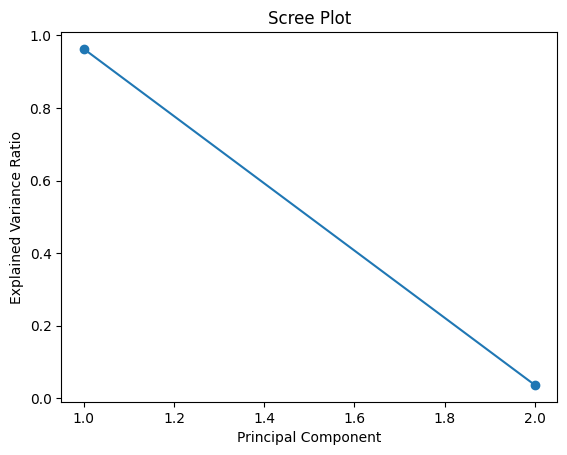

In [9]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

plt.plot(range(1, len(explained_variance_ratio)+1),
         explained_variance_ratio,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()


In [10]:
PC1 = eigenvectors[:, 0]
X_reduced = X_standardized @ PC1
X_reduced


array([ 1.08643242, -2.3089372 ,  1.24191895,  0.34078247,  2.18429003,
        1.16073946, -0.09260467, -1.48210777, -0.56722643, -1.56328726])

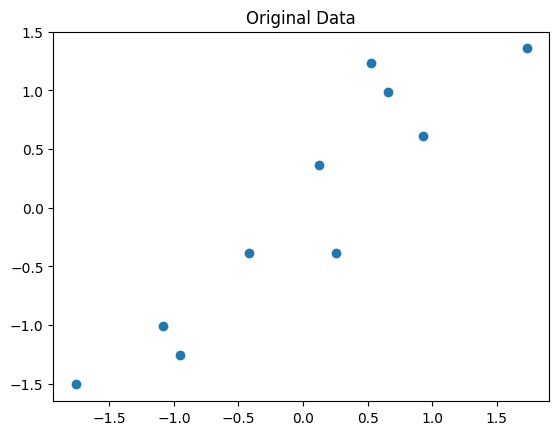

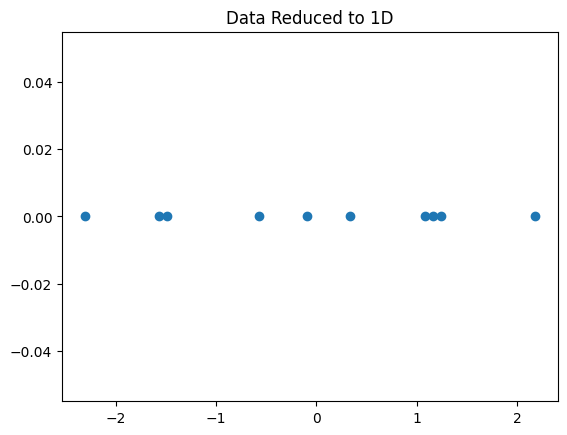

In [11]:
plt.scatter(X_standardized[:, 0], X_standardized[:, 1])
plt.title("Original Data")
plt.show()

plt.scatter(X_reduced, np.zeros_like(X_reduced))
plt.title("Data Reduced to 1D")
plt.show()
